## Evaluation of hysteresis loops

This tutorial will provide a few examples for the analysis of (magnetic) hysteresis loops possible with Evaluix. The analysis is mainly based on arctan functions which empirically mimic the magnetization reversal during the decreasing and increasing field branches.
In total there are four functions for analyzing hysteresis loops:
1. ``lin_hyseval``
2. ``arctan_hyseval``
3. ``double_arctan_hyseval``
4. ``mult_arctan_hyseval``  

Whereby 3. and 4. are only combinations of the ``arctan_hyseval`` function for cases were several loops exist in a single hysteresis curve.

The first part of this tutorial explains ``lin_hyseval`` and ``arctan_hyseval`` and the characterisitc quantities which are calculated by them. In the second part of the tutorial the simultaneous fit of several loops is discussed.

In [7]:
from pathlib import Path

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import pandas as pd

from evaluix.utils import hysteresis_functions as hf

csv_path = Path.cwd().parent / "_static" / "simulated" / "simulated_hysteresis_loop.csv"
data = pd.read_csv(csv_path)
fields = data.iloc[:, 0].values
magnetization = data.iloc[:, 1].values

print(data.head())

   Applied Field (H [arb. u.])  Normalized Magnetization
0                        200.0                  0.999597
1                        199.0                  0.991704
2                        198.0                  0.998509
3                        197.0                  0.997402
4                        196.0                  0.999883


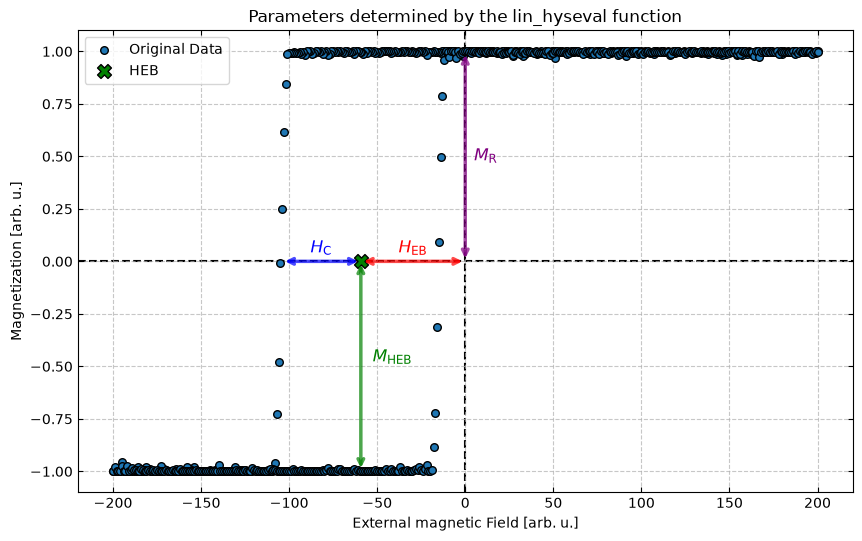

In [2]:
lin_params = hf.lin_hyseval(fields, magnetization)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(fields, magnetization, label='Original Data', edgecolor='k', s=30, zorder=5)
ax.scatter(lin_params['HEB'], 0, color='g', label='HEB', zorder=10, s=100, edgecolor='k', marker='X')
ax.set_title('Parameters determined by the lin_hyseval function')
ax.set_xlabel('External magnetic Field [arb. u.]')
ax.set_ylabel('Magnetization [arb. u.]')
ax.tick_params(direction='in', top=True, right=True)
ax.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
ax.axvline(0, color='k', linestyle='--', zorder=1)
ax.axhline(0, color='k', linestyle='--', zorder=1)

# HEB arrow from 0 to HEB with text above the arrow
heb_y = 0
ax.annotate(
    '',
    xy=(lin_params['HEB'], 0),
    xytext=(0, 0),
    arrowprops={"arrowstyle": '<->', "facecolor": 'red', "edgecolor": 'red', "lw": 2.5, 'alpha': 0.7},
    zorder=10,
 )
ax.text(
    0.5 * lin_params['HEB'],
    0.02,
    r'$H_\mathrm{EB}$',
    color='red',
    fontsize=12,
    ha='center',
    va='bottom',
    zorder=11,
 )

# HC arrow from HEB to HEB - HC with text above the arrow
ax.annotate(
    '',
    xy=(lin_params['HEB'] - lin_params['HC'], 0),
    xytext=(lin_params['HEB'], 0),
    arrowprops={"arrowstyle": '<->', "facecolor": 'blue', "edgecolor": 'blue', "lw": 2.5, 'alpha': 0.7},
    zorder=10,
 )
ax.text(
    lin_params['HEB'] - 0.5 * lin_params['HC'],
    0.02,
    r'$H_\mathrm{C}$',
    color='blue',
    fontsize=12,
    ha='center',
    va='bottom',
    zorder=11,
 )

# MHEB from 0 to -MHEB at x=HEB with text to the right of the arrow
ax.annotate(
    '',
    xy=(lin_params['HEB'], 0),
    xytext=(lin_params['HEB'], -lin_params['MHEB'][0]),
    arrowprops={"arrowstyle": '<->', "facecolor": 'green', "edgecolor": 'green', "lw": 2.5, 'alpha': 0.7},
    zorder=10,
    )
ax.text(
    0.7 * lin_params['HEB'],
    - 0.5 *lin_params['MHEB'][0],
    r'$M_\mathrm{HEB}$',
    color='green',
    fontsize=12,
    ha='center',
    va='bottom',
    zorder=11,
    )

# MR from 0,0 to 0,MR with text to the right of the arrow
ax.annotate(
    '',
    xy=(0, lin_params['MR'][0]),
    xytext=(0, 0),
    arrowprops={"arrowstyle": '<->', "facecolor": 'purple', "edgecolor": 'purple', "lw": 2.5, 'alpha': 0.7},
    zorder=10,
 )
ax.text(
    5, 0.5 * lin_params['MR'][0],
    r'$M_\mathrm{R}$',
    color='purple',
    fontsize=12,
    ha='left',
    va='center',
    zorder=11,
 )
plt.legend()
plt.show()

## arctan_hyseval


HEB_1: -60.0318
dHEB_1: 0.5177
HC_1: 44.8250
dHC_1: 0.5176
MS_1: 1.0074
dMS_1: 0.0018
MR_1: (np.float64(0.9845551874275427), np.float64(0.9996776993756802), np.float64(0.969432675479405))
dMR_1: 0.0019
MHEB_1: (np.float64(0.995357622881306), np.float64(0.9928001742569638), np.float64(-0.9979150715056483))
dMHEB_1: 0.0020
saturation_fields_1: (np.float64(-25.87751650576506), np.float64(-94.1860230603544))
dsaturation_fields_1: 0.7915
slope_atHC_1: 1.1995
dslope_atHC_1: 0.0298
slope_atHEB_1: 0.0004
dslope_atHEB_1: 0.0000
alpha_1: 1.5240
dalpha_1: 0.0002
rectangularity_1: 0.9989
drectangularity_1: 0.0000
integral_1: 180.0767
dintegral_1: 0.0000
a: -0.0026
da: 0.0009
b_1: 1.0074
db_1: 0.0009
c_1: 1.1907
dc_1: 0.0285
d_1: -60.0318
dd_1: 0.0183
e_1: 44.8250
de_1: 0.0182
r_squared: 0.9994
chi_squared: 0.4170


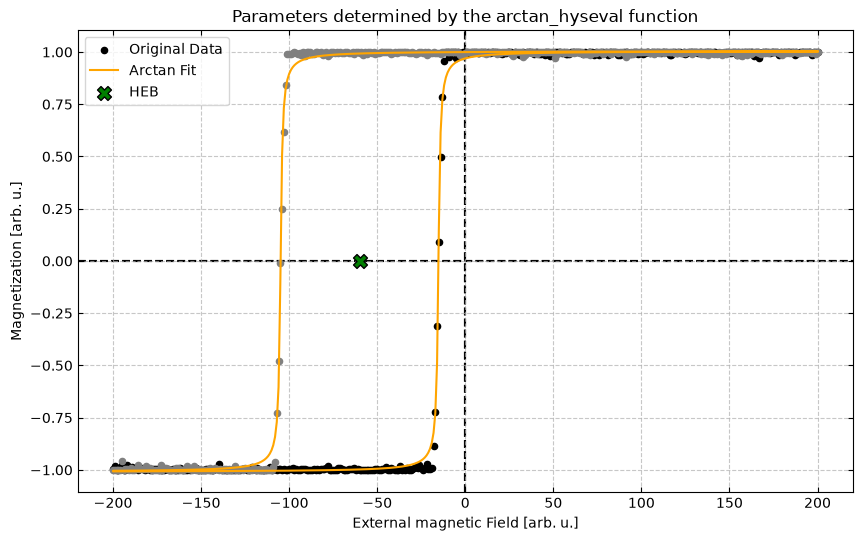

In [14]:
arctan_fit, arctan_params, arctan_results = hf.arctan_hyseval(fields, magnetization)

for key, value in arctan_params.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")
        

fig, ax = plt.subplots(figsize=(10, 6))
hf.plot_loop(fields, magnetization, ax=ax, label='Original Data', plotstyle='scatter', color=['k', 'grey'])
# ax.scatter(fields, magnetization, label='Original Data', edgecolor='k', s=30, zorder=5)
ax.plot(arctan_fit['xdata'], arctan_fit['ydata'], label='Arctan Fit', color='orange', zorder=6)
ax.scatter(arctan_params['HEB_1'], 0, color='g', label='HEB', zorder=10, s=100, edgecolor='k', marker='X')
ax.set_title('Parameters determined by the arctan_hyseval function')
ax.set_xlabel('External magnetic Field [arb. u.]')
ax.set_ylabel('Magnetization [arb. u.]')
ax.tick_params(direction='in', top=True, right=True)
ax.grid(which='both', linestyle='--', alpha=0.7, zorder=0)
ax.axvline(0, color='k', linestyle='--', zorder=1)
ax.axhline(0, color='k', linestyle='--', zorder=1)
plt.legend()
plt.show()
